In [3]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")
X = data.data
y = (data.target == "tested_positive").astype(int)

print("Observations:", X.shape[0])
print("Features    :", X.shape[1])
print("Class distribution:\n", y.value_counts())

Observations: 768
Features    : 8
Class distribution:
 class
0    500
1    268
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score

train_acc = []
test_acc = []
train_auc = []
test_auc = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.values[train_idx], X.values[test_idx]
    y_train, y_test = y.values[train_idx], y.values[test_idx]

    model.fit(X_train, y_train)

    # Accuracy
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

    # AUC
    train_auc.append(roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))
    test_auc.append(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

In [11]:
from scipy import stats
import numpy as np

train_auc = np.array(train_auc)
test_auc = np.array(test_auc)

diff = train_auc - test_auc
mean_diff = diff.mean()
sem_diff = stats.sem(diff)
lower_ci, upper_ci = stats.t.interval(0.95, df=len(diff)-1, loc=mean_diff, scale=sem_diff)

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils import resample

B = 1000
rng = np.random.RandomState(42)

boot_acc, boot_prec, boot_rec, boot_f1, boot_auc = [], [], [], [], []

for _ in range(B):
    X_boot, y_boot = resample(X_test, y_test, random_state=rng)
    y_pred_boot = model.predict(X_boot)
    y_prob_boot = model.predict_proba(X_boot)[:, 1]

    boot_acc.append(accuracy_score(y_boot, y_pred_boot))
    boot_prec.append(precision_score(y_boot, y_pred_boot, zero_division=0))
    boot_rec.append(recall_score(y_boot, y_pred_boot, zero_division=0))
    boot_f1.append(f1_score(y_boot, y_pred_boot, zero_division=0))
    boot_auc.append(roc_auc_score(y_boot, y_prob_boot))

In [15]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "Point Estimate": [
        np.mean(boot_acc),
        np.mean(boot_prec),
        np.mean(boot_rec),
        np.mean(boot_f1),
        np.mean(boot_auc)
    ],
    "95% CI Lower": [
        np.percentile(boot_acc, 2.5),
        np.percentile(boot_prec, 2.5),
        np.percentile(boot_rec, 2.5),
        np.percentile(boot_f1, 2.5),
        np.percentile(boot_auc, 2.5)
    ],
    "95% CI Upper": [
        np.percentile(boot_acc, 97.5),
        np.percentile(boot_prec, 97.5),
        np.percentile(boot_rec, 97.5),
        np.percentile(boot_f1, 97.5),
        np.percentile(boot_auc, 97.5)
    ]
})

results

,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Accuracy,0.620967,0.542484,0.699346
1,Precision,0.458335,0.323518,0.587325
2,Recall,0.511704,0.372873,0.648173
3,F1-Score,0.481393,0.359989,0.592608
4,AUC,0.595327,0.513817,0.677128


DATASET INFORMATION

Observations : 768
Features     : 8

Data Types
preg        int64
plas        int64
pres        int64
skin        int64
insu        int64
mass      float64
pedi      float64
age         int64
target      int64
dtype: object

Missing Values
preg      0
plas      0
pres      0
skin      0
insu      0
mass      0
pedi      0
age       0
target    0
dtype: int64

Statistical Summary


,preg,plas,pres,skin,insu,mass,pedi,age,target
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Class Distribution
class
0    500
1    268
Name: count, dtype: int64


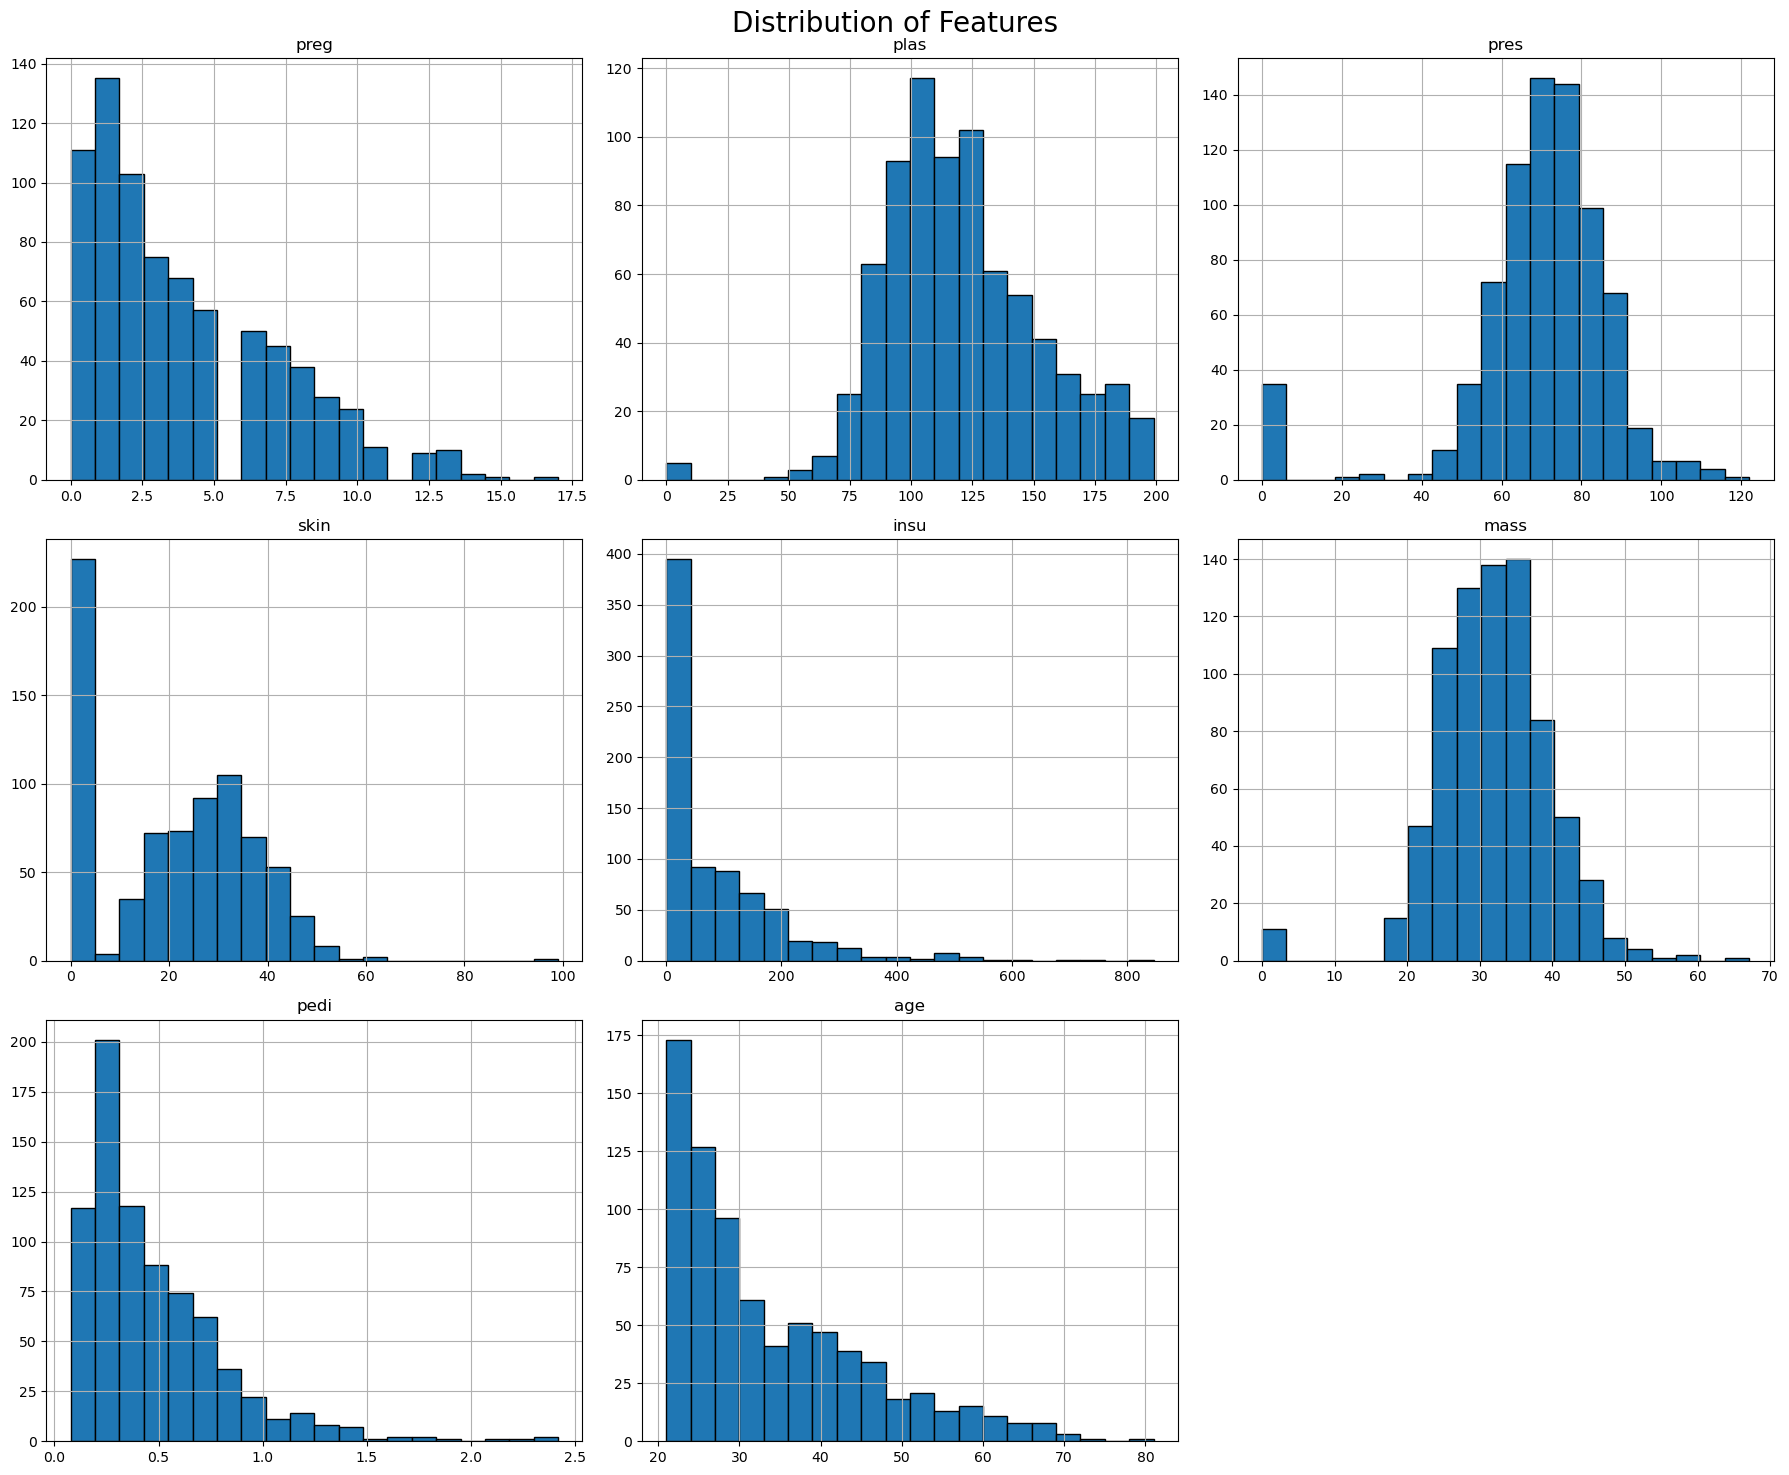

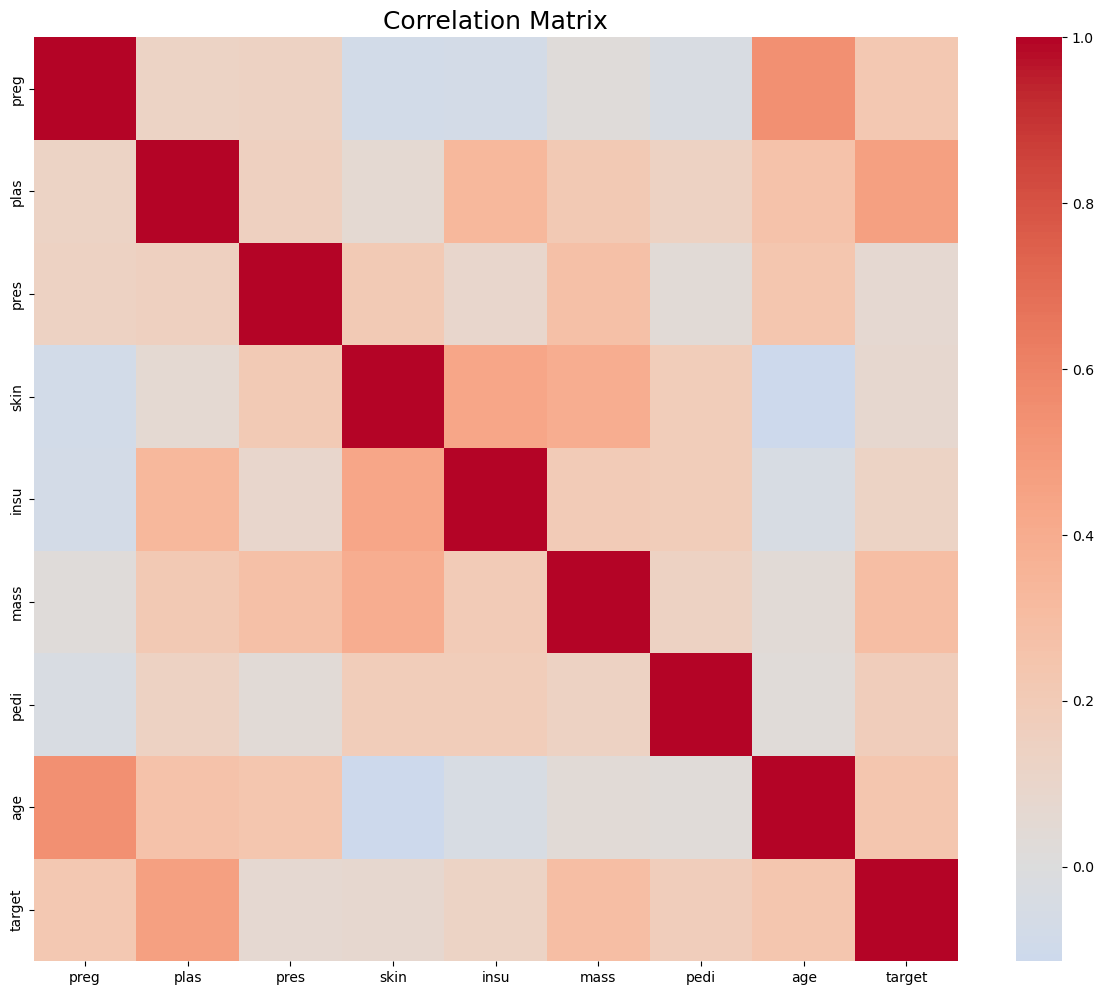

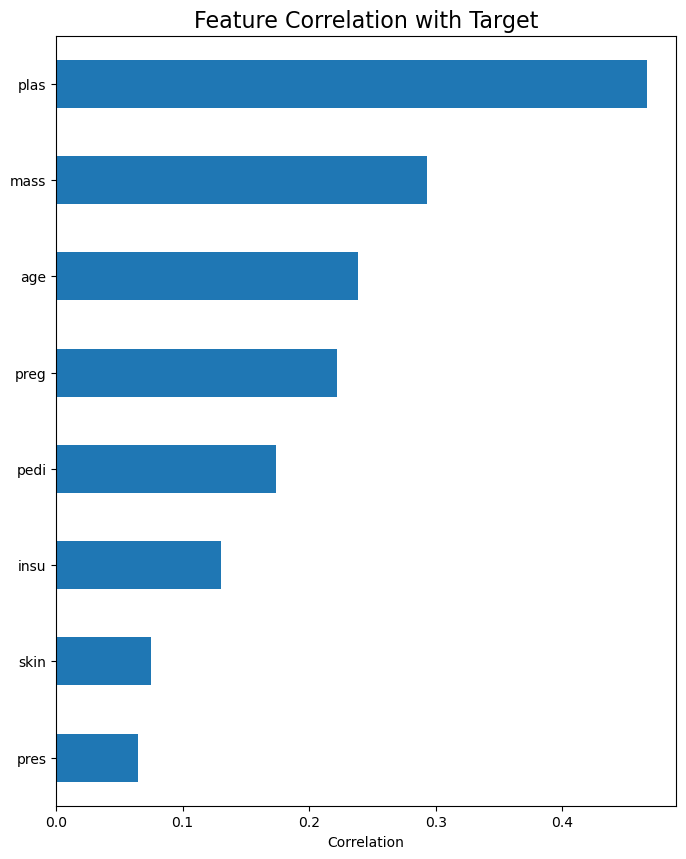

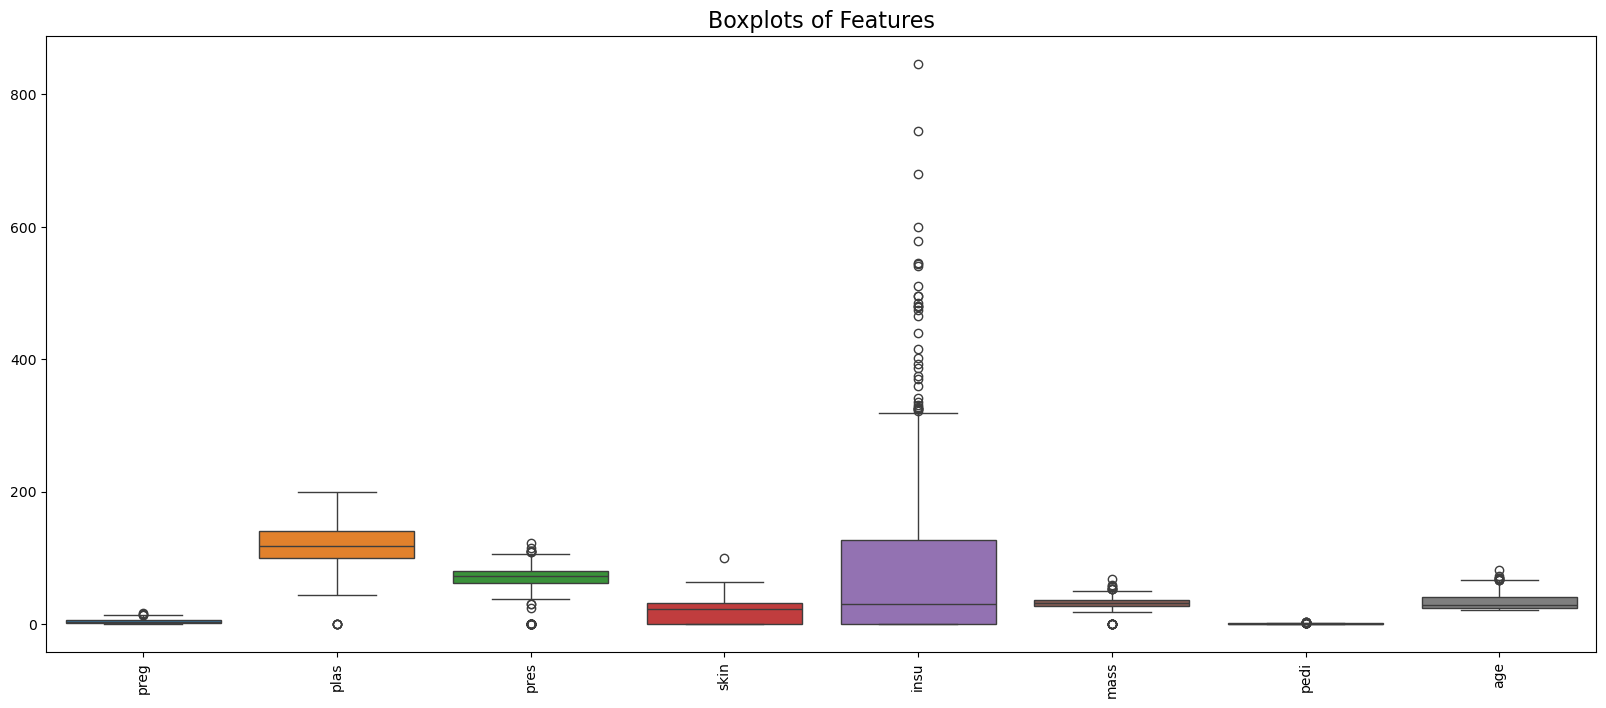

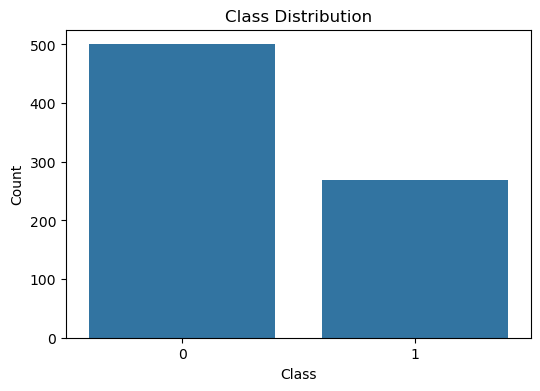

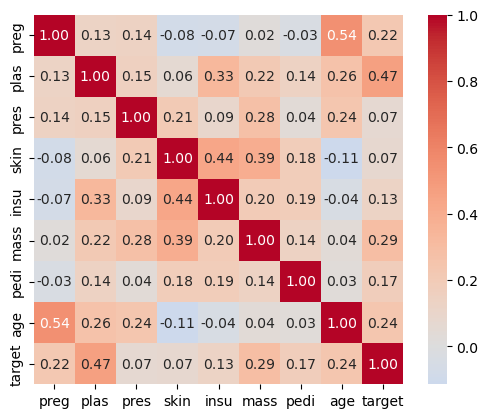

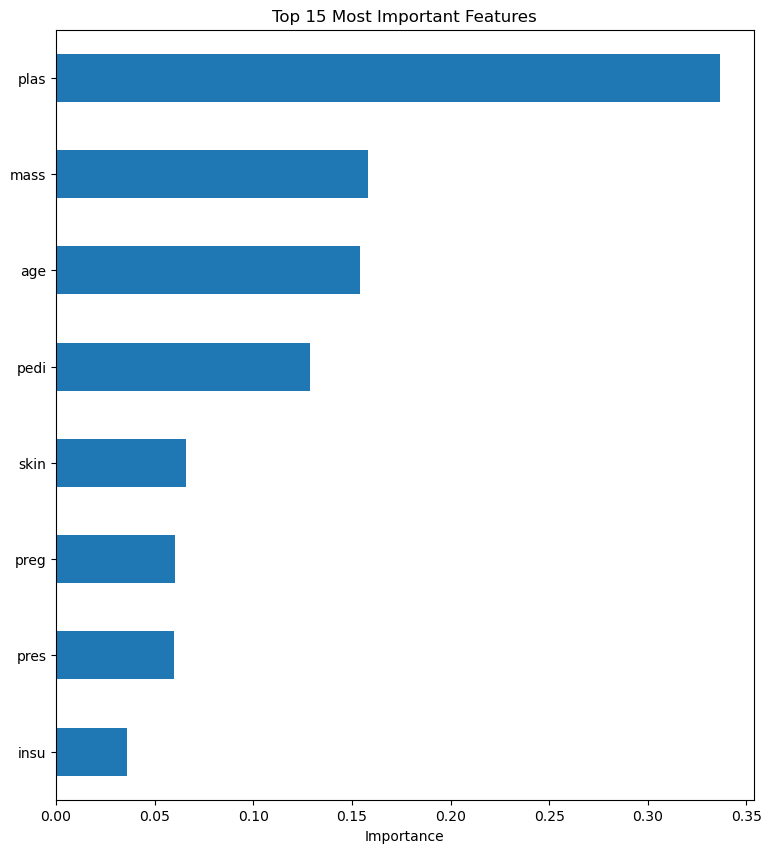

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)
# =====================================================

# Junta X e y
df = X.copy()
df["target"] = y

# -----------------------------------------------------
# Informações gerais
# -----------------------------------------------------
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(f"\nObservations : {X.shape[0]}")
print(f"Features     : {X.shape[1]}")

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
display(df.describe())

print("\nClass Distribution")
print(y.value_counts())

# =====================================================
# HISTOGRAMAS
# =====================================================

df.drop(columns="target").hist(
    figsize=(18,15),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Features", fontsize=20)
plt.tight_layout()
plt.show()

# =====================================================
# MATRIZ DE CORRELAÇÃO
# =====================================================

plt.figure(figsize=(15,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix", fontsize=18)
plt.show()

# =====================================================
# CORRELAÇÃO COM O TARGET
# =====================================================

corr_target = df.corr()["target"].drop("target").sort_values()

plt.figure(figsize=(8,10))

corr_target.plot(kind="barh")

plt.title("Feature Correlation with Target", fontsize=16)
plt.xlabel("Correlation")

plt.show()

# =====================================================
# BOXPLOTS
# =====================================================

plt.figure(figsize=(20,8))

sns.boxplot(data=X)

plt.xticks(rotation=90)

plt.title("Boxplots of Features", fontsize=16)

plt.show()

# =====================================================
# DISTRIBUIÇÃO DAS CLASSES
# =====================================================

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# =====================================================
# PAIRPLOT
# (primeiras 5 variáveis para não ficar muito pesado)
# =====================================================

cols = list(X.columns[:5])
cols.append("target")

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    annot=True,   # mostra os valores
    fmt=".2f"     # formata com 2 casas decimais
)

plt.show()

# =====================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# (somente se o modelo possuir feature_importances_)
# =====================================================

if hasattr(model, "feature_importances_"):

    importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values()

    plt.figure(figsize=(9,10))

    importance.tail(15).plot(kind="barh")

    plt.title("Top 15 Most Important Features")

    plt.xlabel("Importance")

    plt.show()